## 🔧 Options

**Concepts:** [Model options](../routers.md#model-options) · [Solver options](../routers.md#solver-options)

[ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) define _what_ is solved — topology, feeder constraints, balancing — while the solver options configure _how_ the MILP solver searches for it. Both are described in [Model options](../routers.md#model-options) and [Solver options](../routers.md#solver-options).

[ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) is the MILP router's container; [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) and [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) take the subset of the same options they can enforce as ordinary arguments.

This notebook shows how to set them on each router, and what actually happens when a router is asked for something it cannot enforce.

### Model options in practice

The full list of parameters and their permitted values is in [Model options](../routers.md#model-options); [ModelOptions.help()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions.help) prints the same information from Python.

#### Capability of different routers

Not every router can enforce every option — see [What each approach can enforce](../routers.md#what-each-approach-can-enforce). The runs below demonstrate that table.

Import required functions

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter, HGSRouter, MILPRouter, ModelOptions

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

Access ModelOptions help

In [3]:
ModelOptions.help()

topology in {"radial", "branched", "ringed"} default: branched
    Architecture of the subtrees in a solution.

feeder_route in {"straight", "segmented"} default: segmented
    If feeder routes must be ``'straight'`` or can be detoured (``'segmented'``).

feeder_limit in {"unlimited", "exactly", "specified", "minimum", "min_plus1", "min_plus2", "min_plus3"} default: unlimited
    Whether to limit the number of feeders. Both ``'specified'`` (an upper
    bound) and ``'exactly'`` (an exact count) require the additional kwarg
    ``'max_feeders'``. Option ``'balanced'`` is only enforceable if the feeder
    count is pinned to a single value, i.e. ``'minimum'`` or ``'exactly'``.

balanced [bool] default: False
    Whether to enforce balanced subtrees (subtree loads differ at most by one unit).

max_feeders [int] default: 0
    Number of feeders: the maximum if <feeder_limit = "specified">, the exact count if <feeder_limit = "exactly">



Optimize an exemplary location

In [4]:
wfn = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=[(2, 500.0), (5, 800.0), (7, 1000.0)])

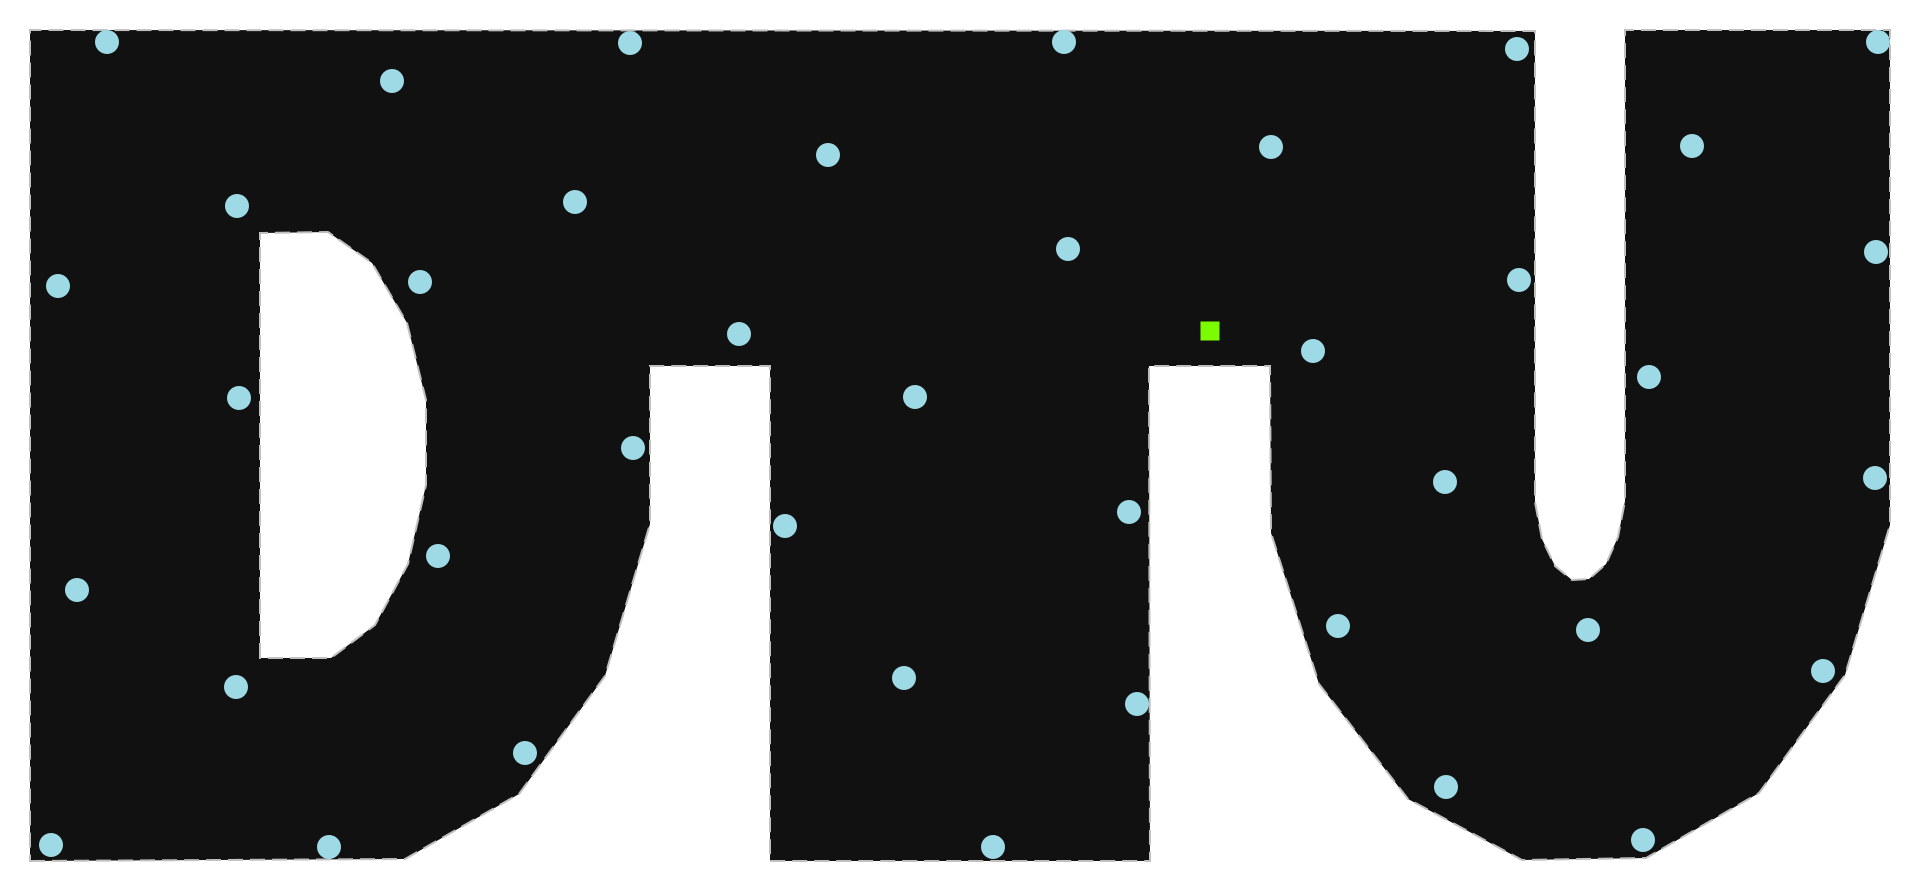

In [5]:
wfn

#### EWRouter

- This router does not accept [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) as an argument.
- The optional EWRouter() parameter [feeder_route](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter.feeder_route) can be set to `'segmented'` (default) or `'straight'`.

Example using `feeder_route='segmented'`

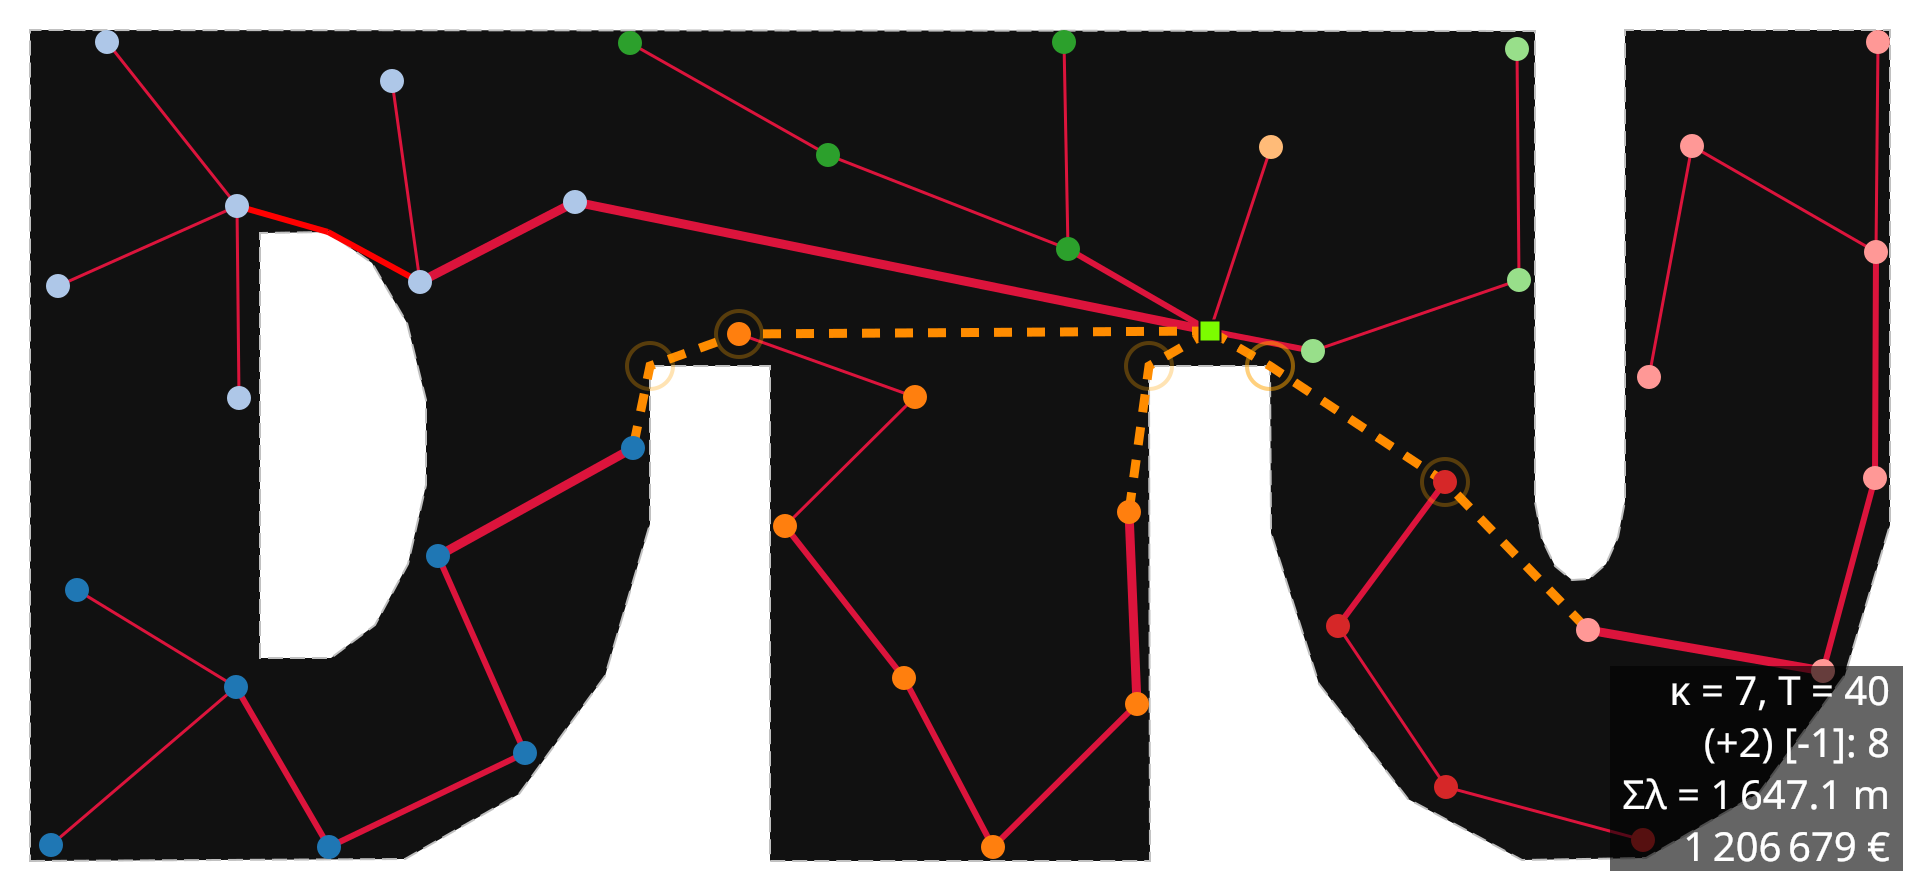

In [6]:
terse = wfn.optimize(router=EWRouter())
wfn

Example using `feeder_route='straight'`

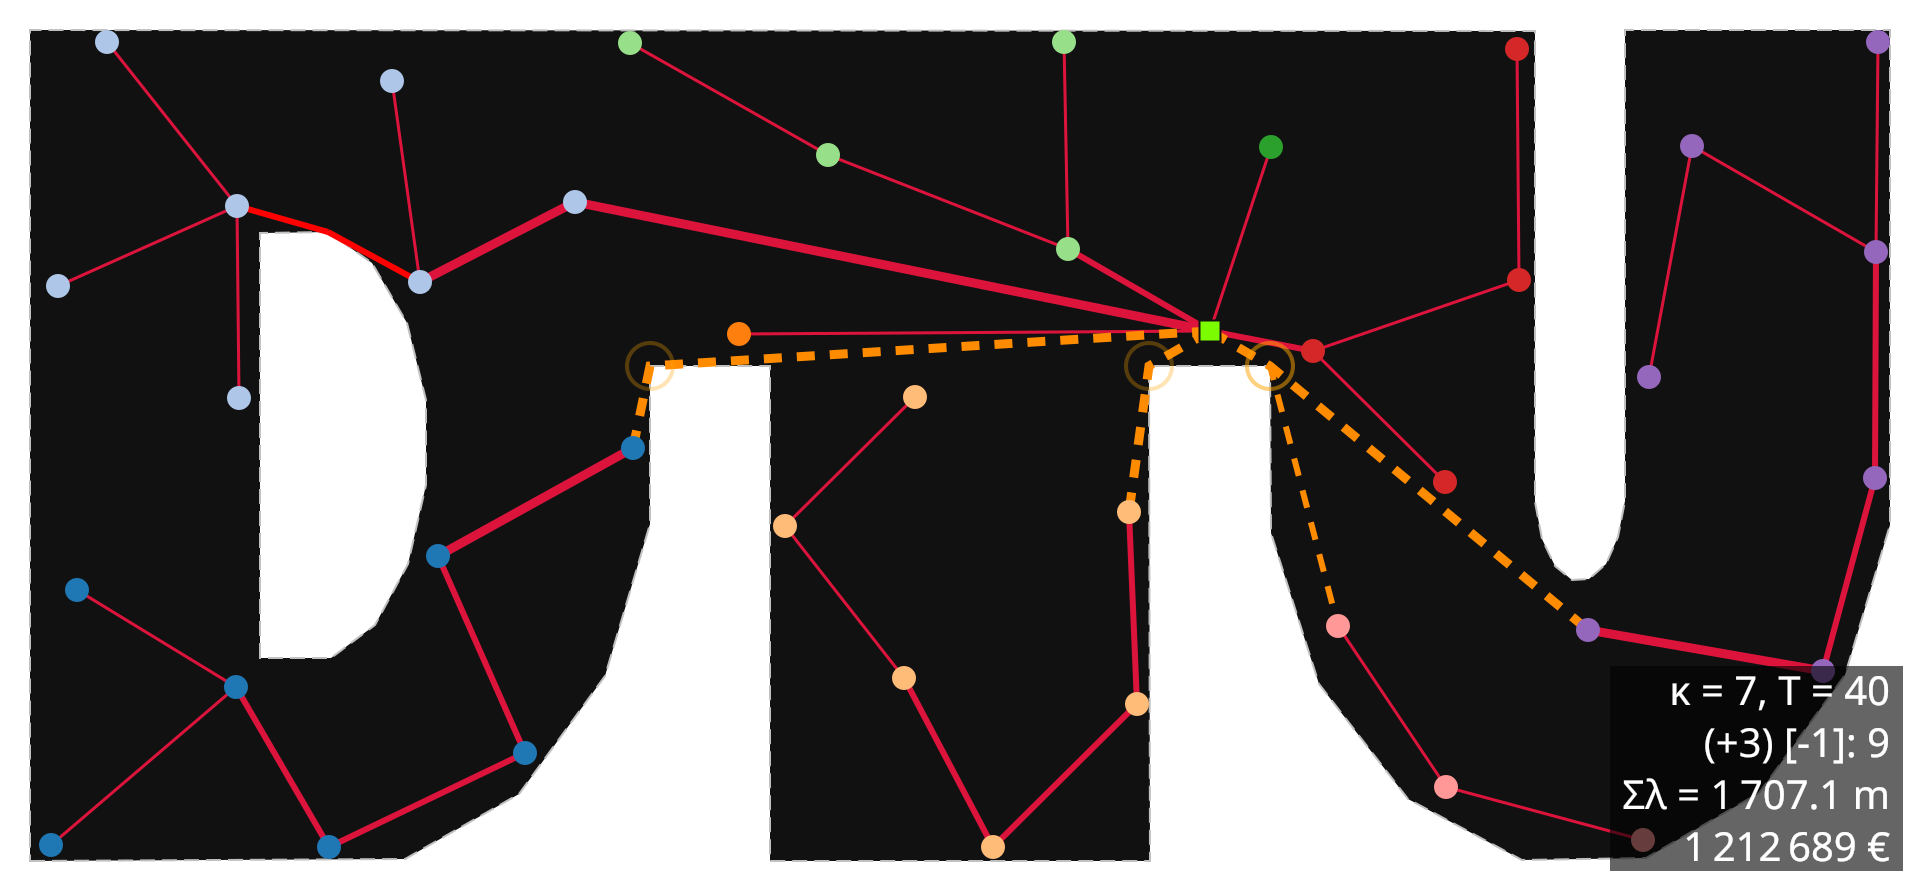

In [7]:
terse = wfn.optimize(router=EWRouter(feeder_route='straight'))
wfn

#### HGSRouter

[HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) does not accept [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) either. Instead, it accepts key configuration options, such as [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) and [balanced](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.balanced), as individual arguments passed directly to the router.

- Default values:

- `balanced = False`
- [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) is flexible and generally favors minimizing total cable length:

- For locations with one substation, [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) can be adjusted.
- For locations with multiple substations, the [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) argument is _ignored_, and the number of feeders is fixed to the minimum required.
- `topology` is chosen by the [ringed](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.ringed) argument — radial by default, ringed with `ringed=True` — and `feeder_route` is not supported. See [What each approach can enforce](../routers.md#what-each-approach-can-enforce).

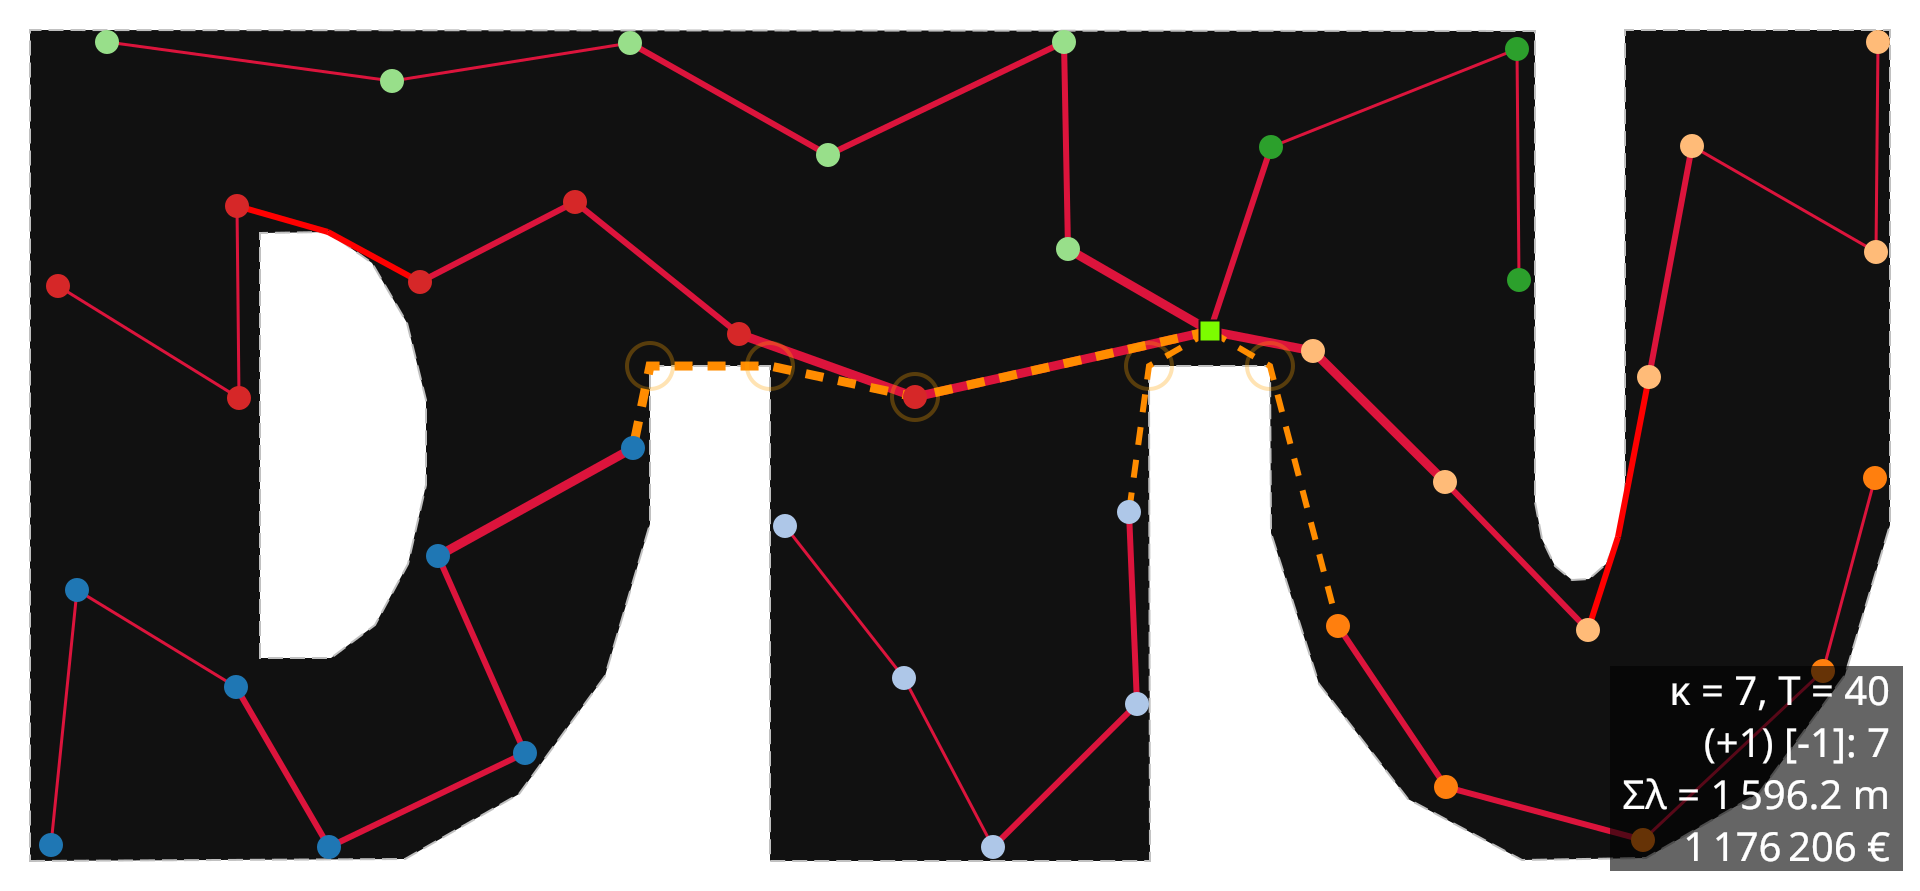

In [8]:
hgs_router = HGSRouter(time_limit=2)
terse = wfn.optimize(router=hgs_router)
wfn

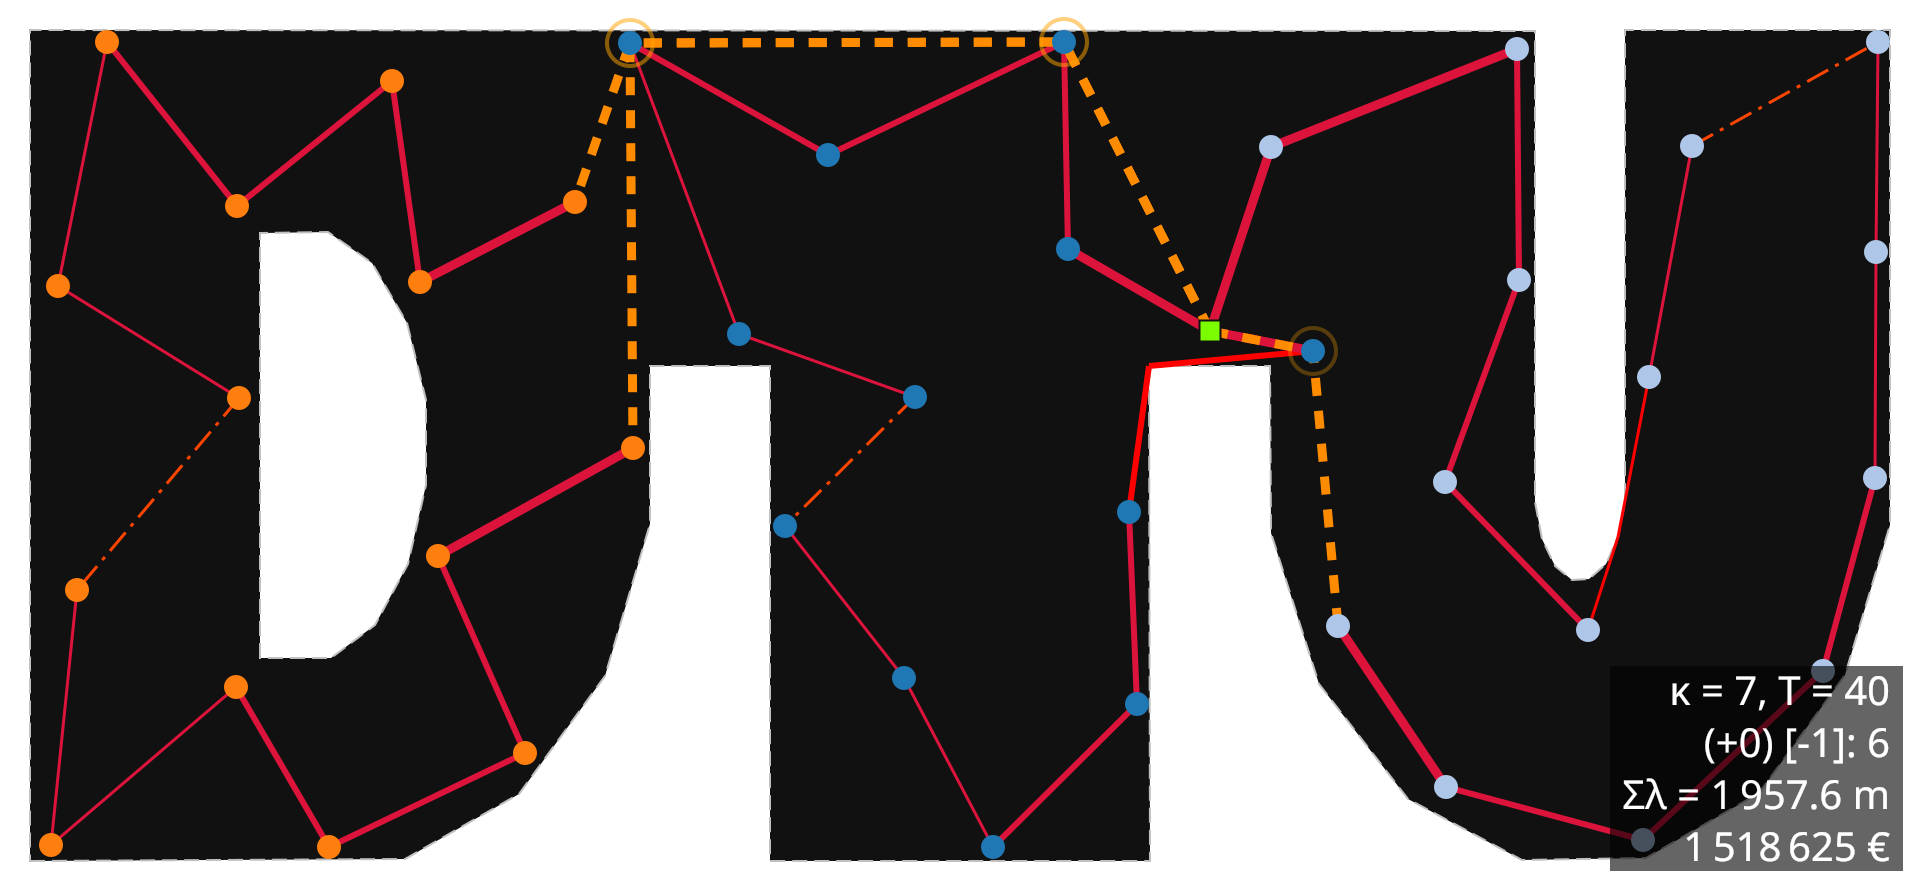

In [9]:
hgs_router = HGSRouter(time_limit=2, ringed=True)
terse = wfn.optimize(router=hgs_router)
wfn

Set the [feeder_limit](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter.feeder_limit) lower than the possible minimum.

Vehicles (feeders) number (0) too low for feasibility with given capacity (7). Setting to 6.


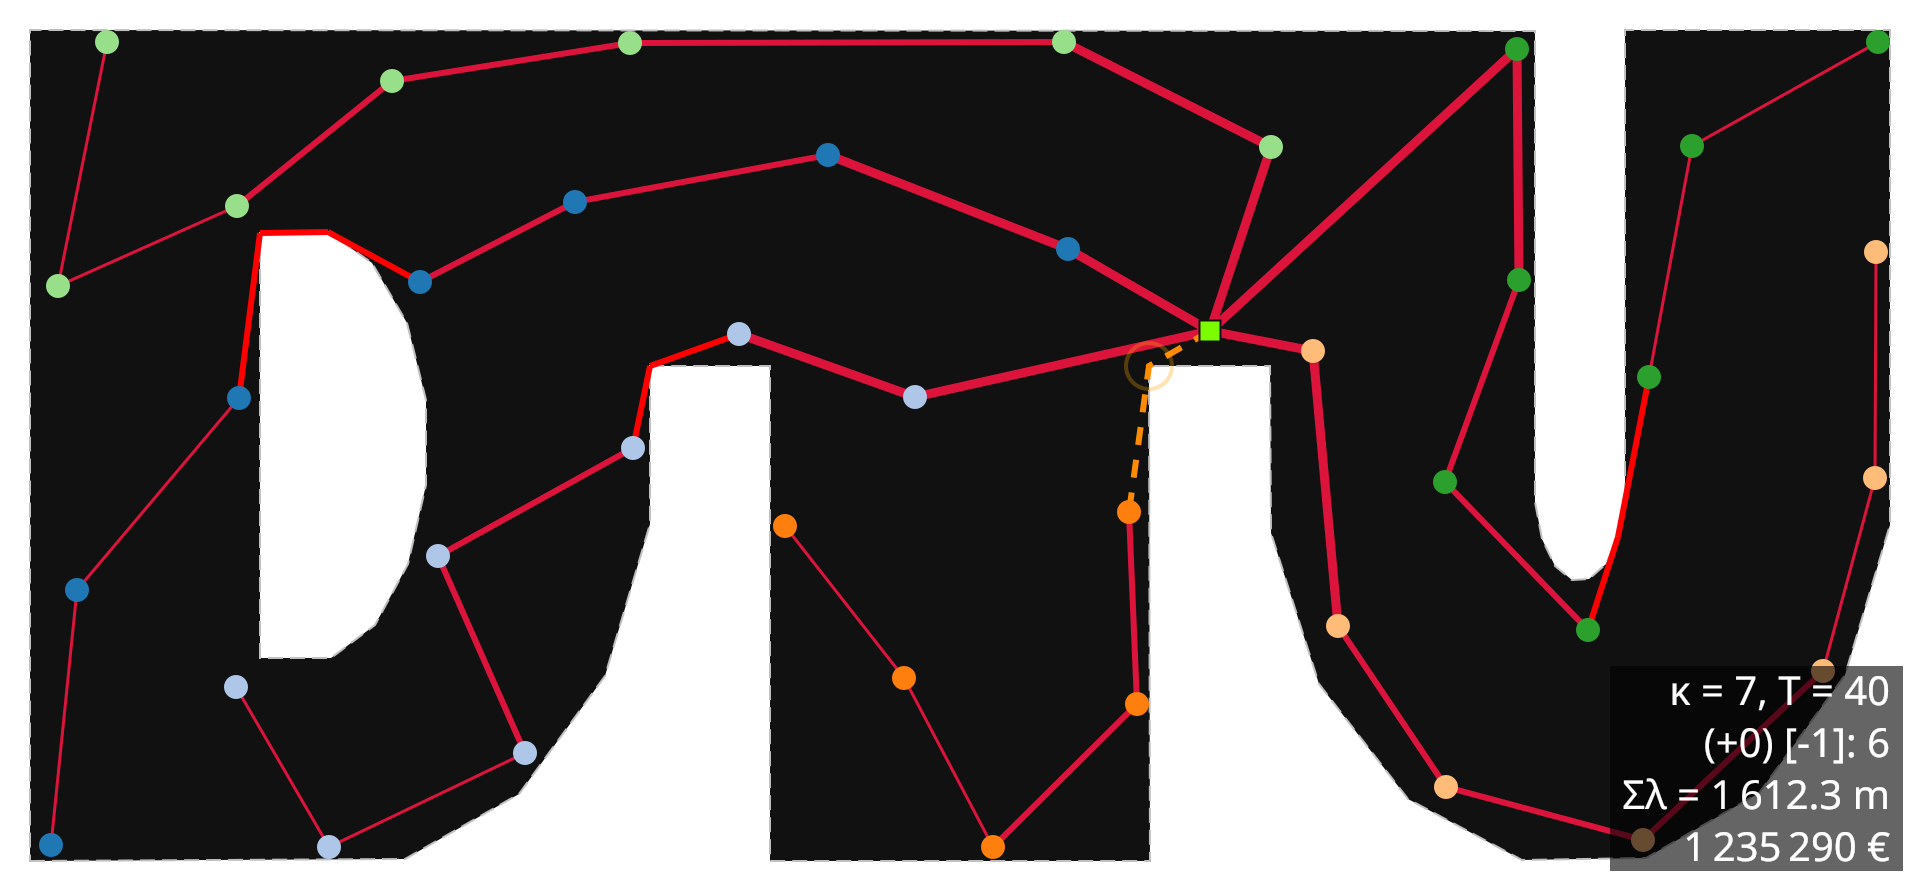

In [10]:
hgs_router2 = HGSRouter(time_limit=2, feeder_limit=0)
terse = wfn.optimize(router=hgs_router2)
wfn

#### MILP routers

[MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) is able to control all settings in [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions).

In this notebook, we run optimization with two sets of ModelOptions for comparison:

| Model Option     | Set 1       | Set 2      |
| ---------------- | ----------- | ---------- |
| **topology**     | `branched`  | `radial`   |
| **feeder_limit** | `unlimited` | `minimum`  |
| **feeder_route** | `segmented` | `straight` |

With `MILP`, we observe the following behavior across different [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions) settings:

##### First MILP Run (`model_options1`)

In [11]:
model_options1 = ModelOptions(
    topology='branched',
    feeder_limit='unlimited',
    feeder_route='segmented',
)

The solver constructs a **branched** network structure without applying any limit on the number of feeders. The feeder routes follow a **segmented**(piecewise-straight) pattern, as specified. All aspects of the network are consistent with the given [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions).

This solution can also serve as a **valid warm start** for subsequent optimizations.

In [12]:
milp_router = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=10,
    mip_gap=0.01,
    model_options=model_options1,
)

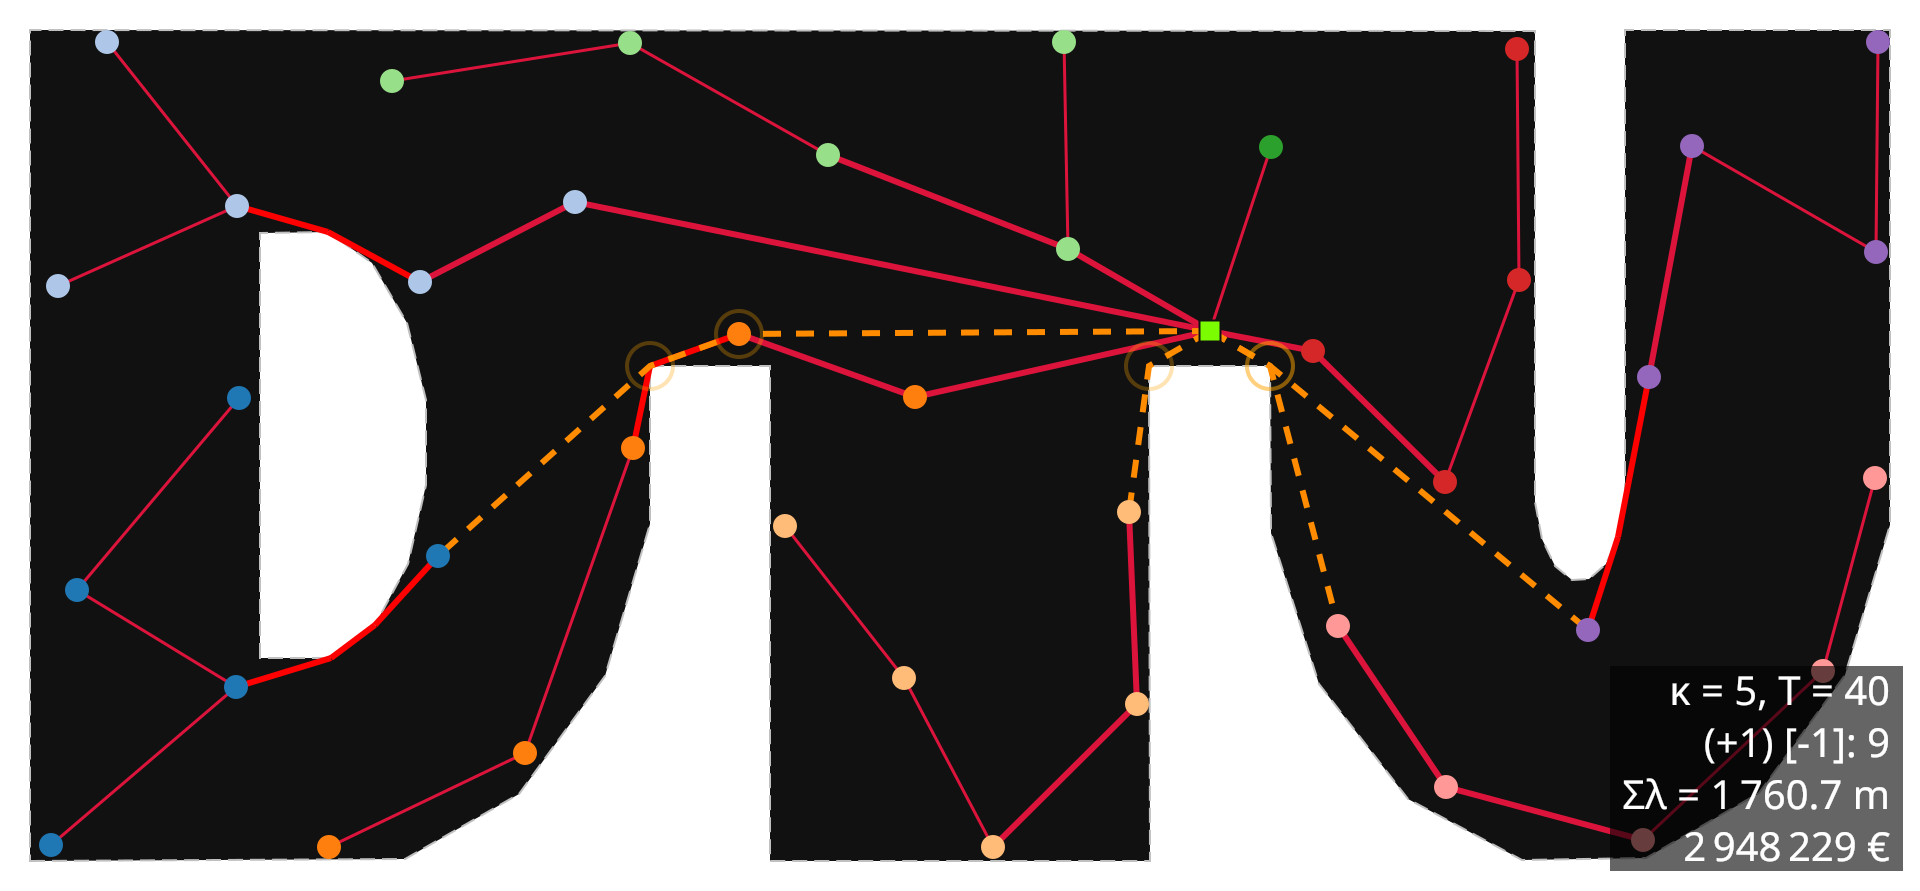

In [13]:
# lower cable capacities to cleary observe the difference between runs
wfn = WindFarmNetwork.from_pbf(
    filepath='data/DTU_letters.osm.pbf',
    cables=[(2, 1500.0), (5, 1800.0)],
)
terse = wfn.optimize(router=milp_router)
wfn

##### Second MILP Run (`model_options2`)

In [14]:
model_options2 = ModelOptions(
    topology='radial',
    feeder_limit='minimum',
    feeder_route='straight',
)

The solver produces a strictly **radial** network, restricting the number of feeders to the minimum required given the number or turbines and maximum cable capacity. The `feeder_route='straight'` tells the solver to avoid blocking any feeder route with cables which tends to produce more **straight-line connections**, although the feeder routes may still have bends due to the exclusion zones.

> Note: with this setting, neither EWRouter nor HGSRouter could secure warmstarting of the model.

Unable to warm-start model: solving without a warm start.


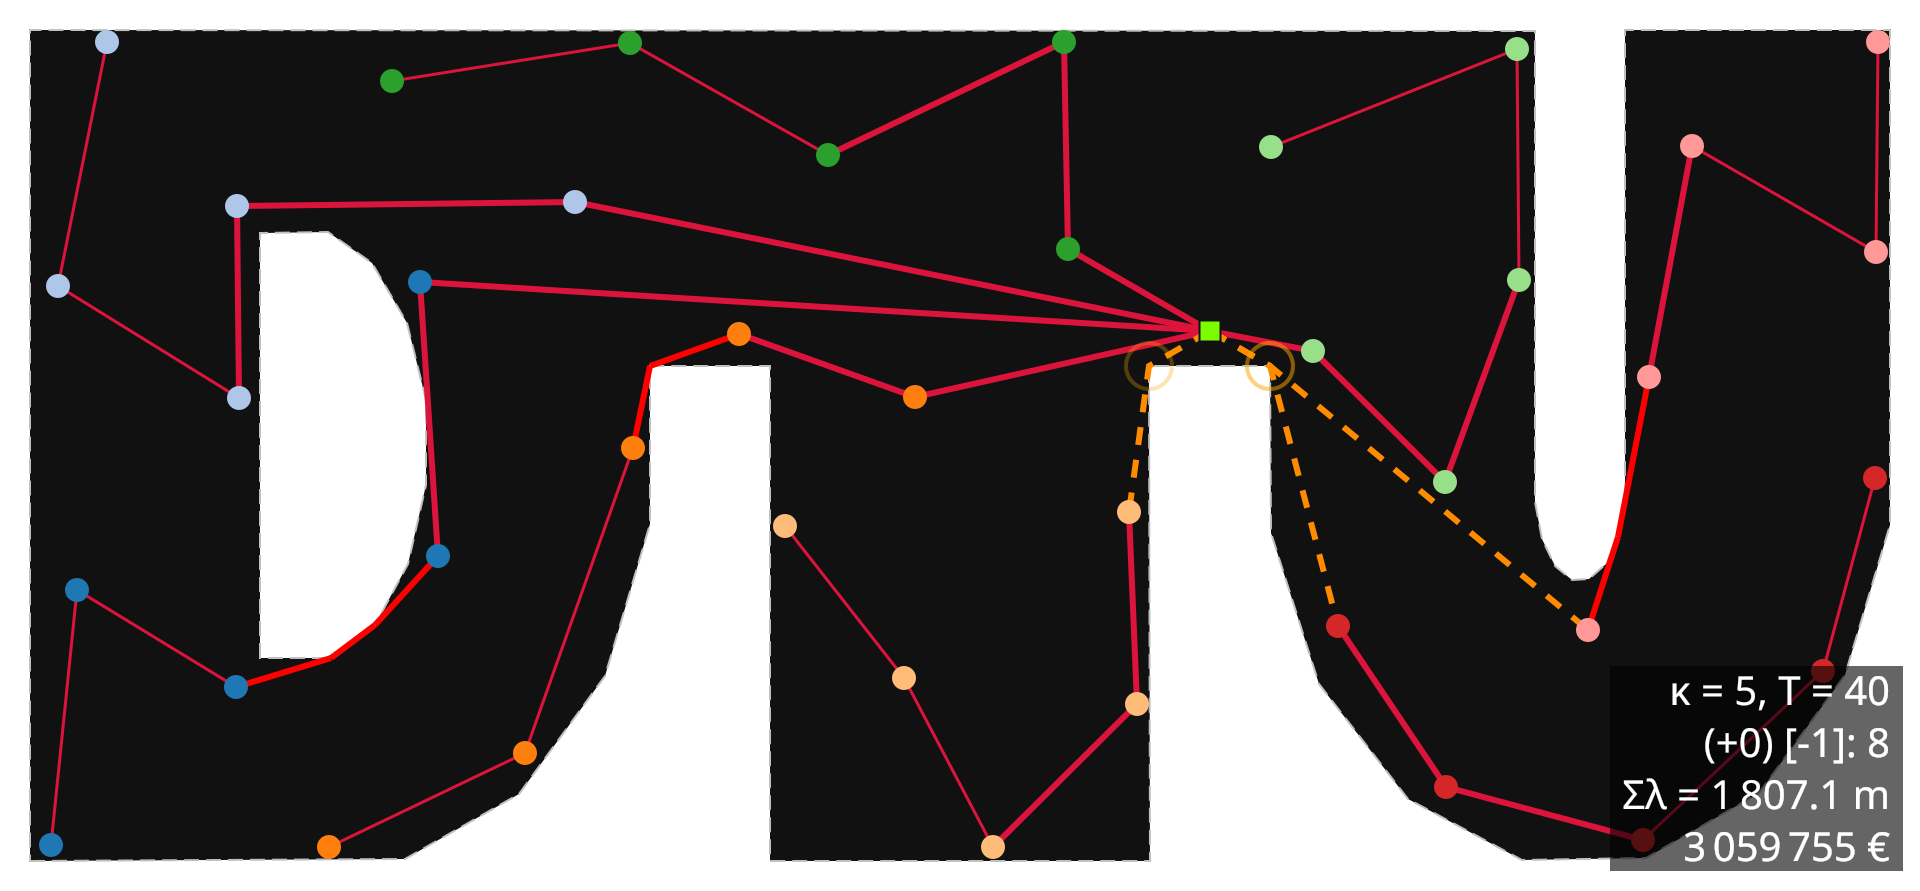

In [15]:
milp_router2 = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=10,
    mip_gap=0.01,
    model_options=model_options2
)
terse = wfn.optimize(router=milp_router2)
wfn

##### Summary

The `MILP` router strictly adheres to all provided [ModelOptions](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.ModelOptions):

- It guarantees enforcement of topology (`branched` vs. `radial`).
- It respects feeder constraints (`unlimited` vs. `minimum`).
- It conforms to the required routing structure (`segmented` vs. `straight`).

##### Warmstarting of MILP routers

Which router can warm-start which model is summarized in [Warm-starting](../routers.md#warm-starting). The examples below illustrate that table.

When the warm start it is given is not valid for the model, [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) does not fail: it quietly warm-starts using an appropriate fast solver. The solver's metadata names the creator of the warm start that was actually used: `milp_router.solver.metadata.warmed_by`.

If it contains `'constructor'`, it means the solution from EWRouter warm-started the model, while if it is `'baselines.hgs'` means HGS did — either the HGSRouter solution given to it, or the fallback that silently replaced a rejected warm start.

Example 1:

In [16]:
model_options = ModelOptions(
    topology='branched',
    feeder_limit='unlimited',
    feeder_route='segmented',
)

In [17]:
milp_router = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=1,
    mip_gap=0.01,
    model_options=model_options,
)

Either EWRouter or HGSRouter can be used to warmstart.

In [18]:
wfn.optimize(router=EWRouter())
terse = wfn.optimize(router=milp_router)
milp_router.solver.metadata.warmed_by, wfn.solution_info()['objective']

('constructor', 1758.4143925147991)

Example 2:

In [19]:
model_options = ModelOptions(
    topology='radial',
    feeder_limit='unlimited',
    feeder_route='segmented',
)

In [20]:
milp_router = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=1,
    mip_gap=0.01,
    model_options=model_options,
)

Now the solution by EWRouter is not a feasible warmstart, so HGSRouter is used under the hood.

In [21]:
wfn.optimize(router=EWRouter())
terse = wfn.optimize(router=milp_router)
milp_router.solver.metadata.warmed_by, wfn.solution_info()['objective']

('baselines.hgs', 1765.3337583487717)

### Solver options in practice

Solver options are passed to the MILP solver itself and affect only how it searches — the parameters are listed in [Solver options](../routers.md#solver-options). [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) takes `time_limit`, `mip_gap` and `verbose` as arguments of its own, and forwards whatever is in its `solver_options` mapping to the backend.

After initializing the router, _OptiWindNet_ sets a few defaults matching its preferred values. You can see the ones it modified via:

```python
router.optiwindnet_default_options
```

If desired, set the logging level to `INFO` _before running [.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) with the MILPRouter_ to display detailed messages about the solver configuration:

```python
import logging
logging.basicConfig(level=logging.INFO)
```

In [22]:
milp_router_ortools = MILPRouter(solver_name='ortools.cp_sat', time_limit=15, mip_gap=0.01)
milp_router_ortools.optiwindnet_default_options

{}

In [23]:
milp_router_cplex = MILPRouter(solver_name='cplex', time_limit=15, mip_gap=0.01)
milp_router_cplex.optiwindnet_default_options

{'parallel': -1, 'emphasis_mip': 4}

In [24]:
milp_router_cbc = MILPRouter(solver_name='cbc', time_limit=15, mip_gap=0.01)
milp_router_cbc.optiwindnet_default_options

{'threads': 8,
 'timeMode': 'elapsed',
 'nodeStrategy': 'downFewest',
 'Dins': 'on',
 'VndVariableNeighborhoodSearch': 'on',
 'Rens': 'on',
 'mixedIntegerRoundingCuts': 'on',
 'flowCoverCuts': 'on',
 'cliqueCuts': 'off',
 'knapsackCuts': 'off',
 'zeroHalfCuts': 'off'}

In [25]:
milp_router_gurobi = MILPRouter(solver_name='gurobi', time_limit=15, mip_gap=0.01)
milp_router_gurobi.optiwindnet_default_options

{'mipfocus': 1}

The last two solvers cannot be instantiated in this kernel: it has already loaded OR-Tools, and [solver_factory()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.solver_factory) refuses to place `'highs'` or `'scip'` in the same Python interpreter instance as `'ortools*'`, which links its own copies of the HiGHS and SCIP libraries (see [MILP Solvers](../reference/solvers.md)).

The HiGHS defaults do not need a solver, though: they are declared at module level in `optiwindnet/MILP/pyomo.py`, so reading them loads neither **highspy** nor OR-Tools.

In [26]:
from optiwindnet.MILP.pyomo import _default_options

_default_options['highs']

{'parallel': 'on'}

SCIP's defaults can be shown following the pattern above. Because ortools has already been loaded in this python kernel, the code below is not runnable in this notebook. Run it in a fresh kernel to reproduce the output shown (`parallel/maxnthreads` follows the machine's physical core count):

```python
milp_router_scip = MILPRouter(solver_name='scip', time_limit=15, mip_gap=0.01)
milp_router_scip.optiwindnet_default_options
```

```
{'parallel/maxnthreads': 8,
 'concurrent/scip-feas/prefprio': 0.6,
 'concurrent/scip/prefprio': 0.3,
 'concurrent/scip-cpsolver/prefprio': 0,
 'concurrent/scip-easycip/prefprio': 0,
 'concurrent/scip-opti/prefprio': 0}
```

This attribute contains the options explicitly set by OptiWindNet. Each supported solver typically offers a large set of configurable options, which can be passed to MILPRouter via `solver_options`. For a complete list, please refer to the solver's official documentation or user manual (e.g. [List of options · HiGHS Documentation](https://ergo-code.github.io/HiGHS/dev/options/definitions/), [List of all SCIP parameters](https://scipopt.org/doc/html/PARAMETERS.php), [A Short Guide to the CBC Command Line Interface](http://www.decom.ufop.br/haroldo/files/cbcCommandLine.pdf))

> **Note:** Options passed to MILPRouter do not change the values stored in `optiwindnet_default_options`. However, the updated values will be used when solving the optimization problem.

Solver options (including those set by OptiWindNet as well as additional configurable parameters) can be modified by creating a **dictionary** and passing it to the router. The same approach applies to **model options**.

In [27]:
solver_options=dict(
    num_workers = 5,
)

wfn.optimize(router=MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=1,
    mip_gap=0.01,
    solver_options=solver_options,
))

TerseLinks(scope='topology', topology='branched', T=40, R=1, links=40)

### Summary

See [Model options](../routers.md#model-options) and [Solver options](../routers.md#solver-options) for the full reference.